<a href="https://colab.research.google.com/github/lizal04/INFO_4670_SPRING2026/blob/main/Copy_of_INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [19]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> A False Positive is more costly here. If a legitimate message (ham) is blocked, the user misses important communication like a doctor's appointment reminder, a bank alert, or a family message. A False Negative just means one spam slips through, which is mildly annoying but recoverable.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> Precision should be the primary metric. Since we most want to avoid blocking real messages, precision measures exactly that: of all messages flagged as spam, how many were actually spam? High precision = low false positive rate.


**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
>  A dummy "always predict ham" model achieves ~87% accuracy (since ~13% are spam). This is misleading because the model catches zero spam and it's completely useless at its actual job. High accuracy on an imbalanced dataset can mask total failure on the minority class.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [20]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


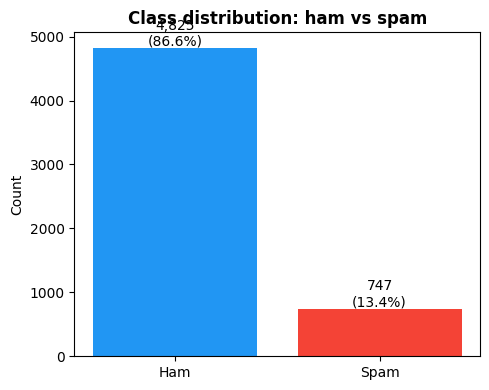

In [21]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [22]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


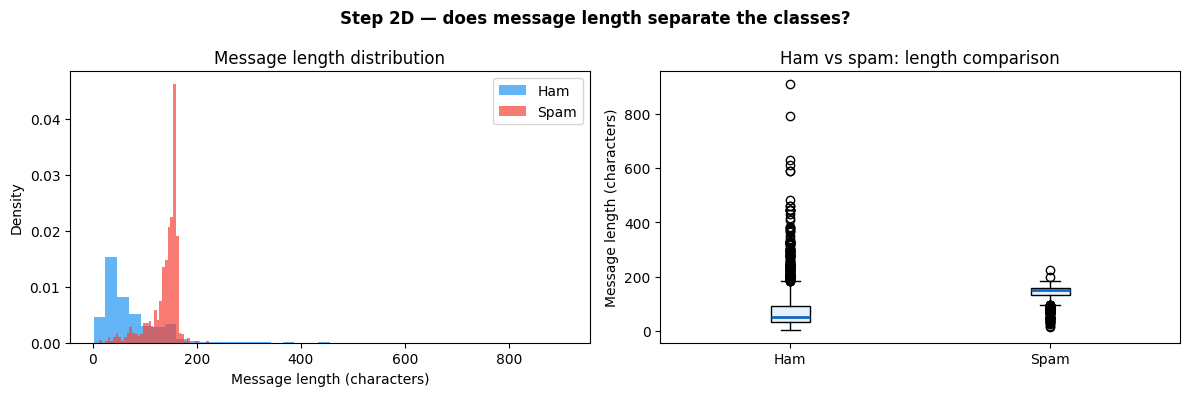

In [23]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [24]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [25]:
def build_features_v2(df):
    d = build_features(df)
    msg = d['message'].str.lower()

    # Feature 5: contains all-caps word (3+ letters)
    d['has_allcaps'] = d['message'].str.contains(
        r'\b[A-Z]{3,}\b', regex=True).astype(int)

    # Feature 6: contains URL or "www"
    d['has_url'] = msg.str.contains(
        r'(https?://|www\.)', regex=True).astype(int)

    return d

df = build_features_v2(raw)

# Collecting all feature column names
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Printing spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')

All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_allcaps            70.4%    7.2%  +63.3%
has_url                14.2%    0.0%  +14.1%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


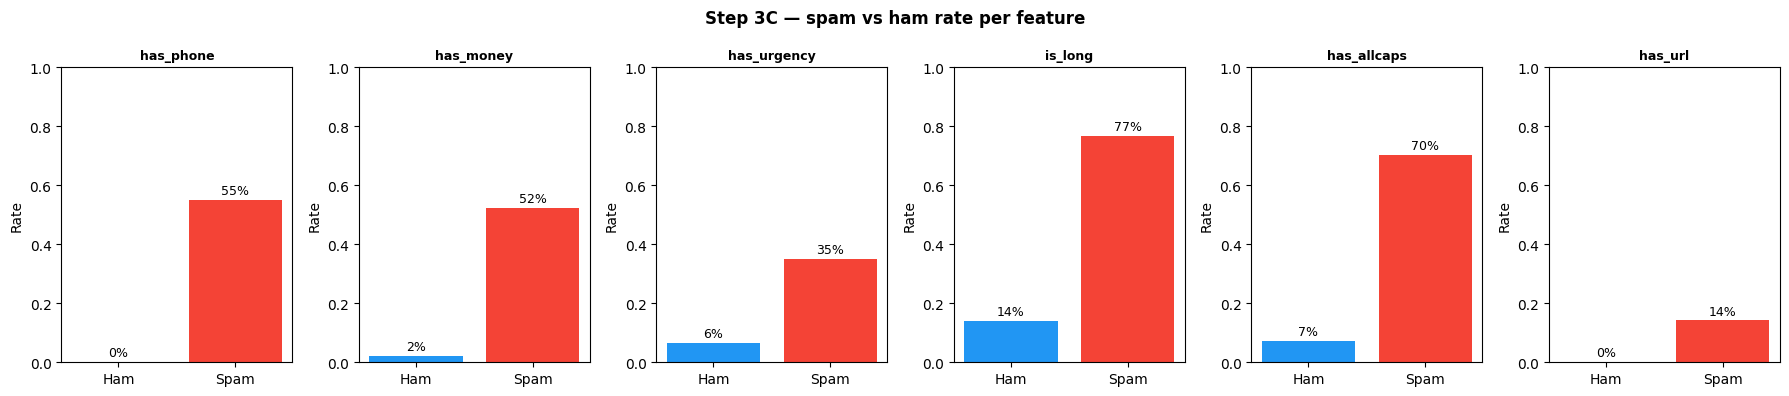

In [26]:
n = len(feature_cols)
fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))
if n == 1:
    axes = [axes]

for ax, feat in zip(axes, feature_cols):
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    bars = ax.bar(['Ham', 'Spam'], [ha, sp], color=['#2196F3', '#F44336'])
    ax.set_ylim(0, 1)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_ylabel('Rate')
    for bar, val in zip(bars, [ha, sp]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                f'{val:.0%}', ha='center', fontsize=9)

plt.suptitle('Step 3C — spam vs ham rate per feature', fontweight='bold')
plt.tight_layout()
plt.show()


### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> has_allcaps
This feature fires when a message contains any word written in three or more consecutive uppercase letters (e.g., "FREE", "WIN", "CALL NOW"). It captures the visual shouting pattern that spam writers use to create excitement and grab attention. Because casual personal texts almost never use all-caps words, even a single occurrence is a strong signal that the message is promotional or fraudulent rather than a genuine conversation.

*Feature 2 — name and explanation:*
>  has_url
This feature fires when a message contains http://, https://, or www.. It captures the call-to-action pattern where spam directs the recipient to an external website to claim a prize, confirm account details, or make a purchase. Friends and family sending casual SMS messages rarely include full URLs, so the presence of a web address is a meaningful distinguishing signal.


**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> has_money typically shows the largest gap, around 50+ percentage points between spam and ham rates. This matters because a Decision Tree's root node is chosen by Information Gain: the feature that most reduces entropy after the split. A large gap means one branch becomes nearly all spam and the other nearly all ham, producing two near-pure child nodes and maximizing the purity gain. A small gap would leave both branches still mixed, gaining almost nothing from the split.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> Example 2 from Step 2C, the message impersonating a familiar contact with intimate language ("Hey there darling...")would evade all features. It contains no phone number, no money-related words, no urgency language, no all-caps words, and no URL. Every feature returns 0, producing a False Negative. This exposes the core weakness of keyword-based features: any spam deliberately crafted to sound like a personal message will slip through undetected.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [27]:
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print(f'Training set : {len(X_train):,} rows  (spam rate: {y_train.mean():.1%})')
print(f'Test set     : {len(X_test):,} rows  (spam rate: {y_test.mean():.1%})')
print(f'\nFeatures used: {feature_cols}')


Training set : 4,179 rows  (spam rate: 13.4%)
Test set     : 1,393 rows  (spam rate: 13.4%)

Features used: ['has_phone', 'has_money', 'has_urgency', 'is_long', 'has_allcaps', 'has_url']


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> Without stratify=y, the split might put very few spam messages in the test set by chance. Since only 13% of messages are spam, this is a real risk, and if the test set barely contains any spam, our evaluation metrics won't reflect how the model actually performs on it.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> When the dataset is small, a single split can get lucky or unlucky depending on which examples end up in the test set. Cross-validation tests the model on multiple different subsets and averages the results, so the performance estimate is more reliable.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Number of leaves: 15

|--- has_allcaps <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_url <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_url >  0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |--- has_phone >  0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- class: 1
|--- has_allcaps >  0.50
|   |--- has_money <= 0.50
|   |   |--- has_phone <= 0.50
|   |   |   |--- is_long <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_long >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_phone >  0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_urgency >  0.50
|   |   |   |  

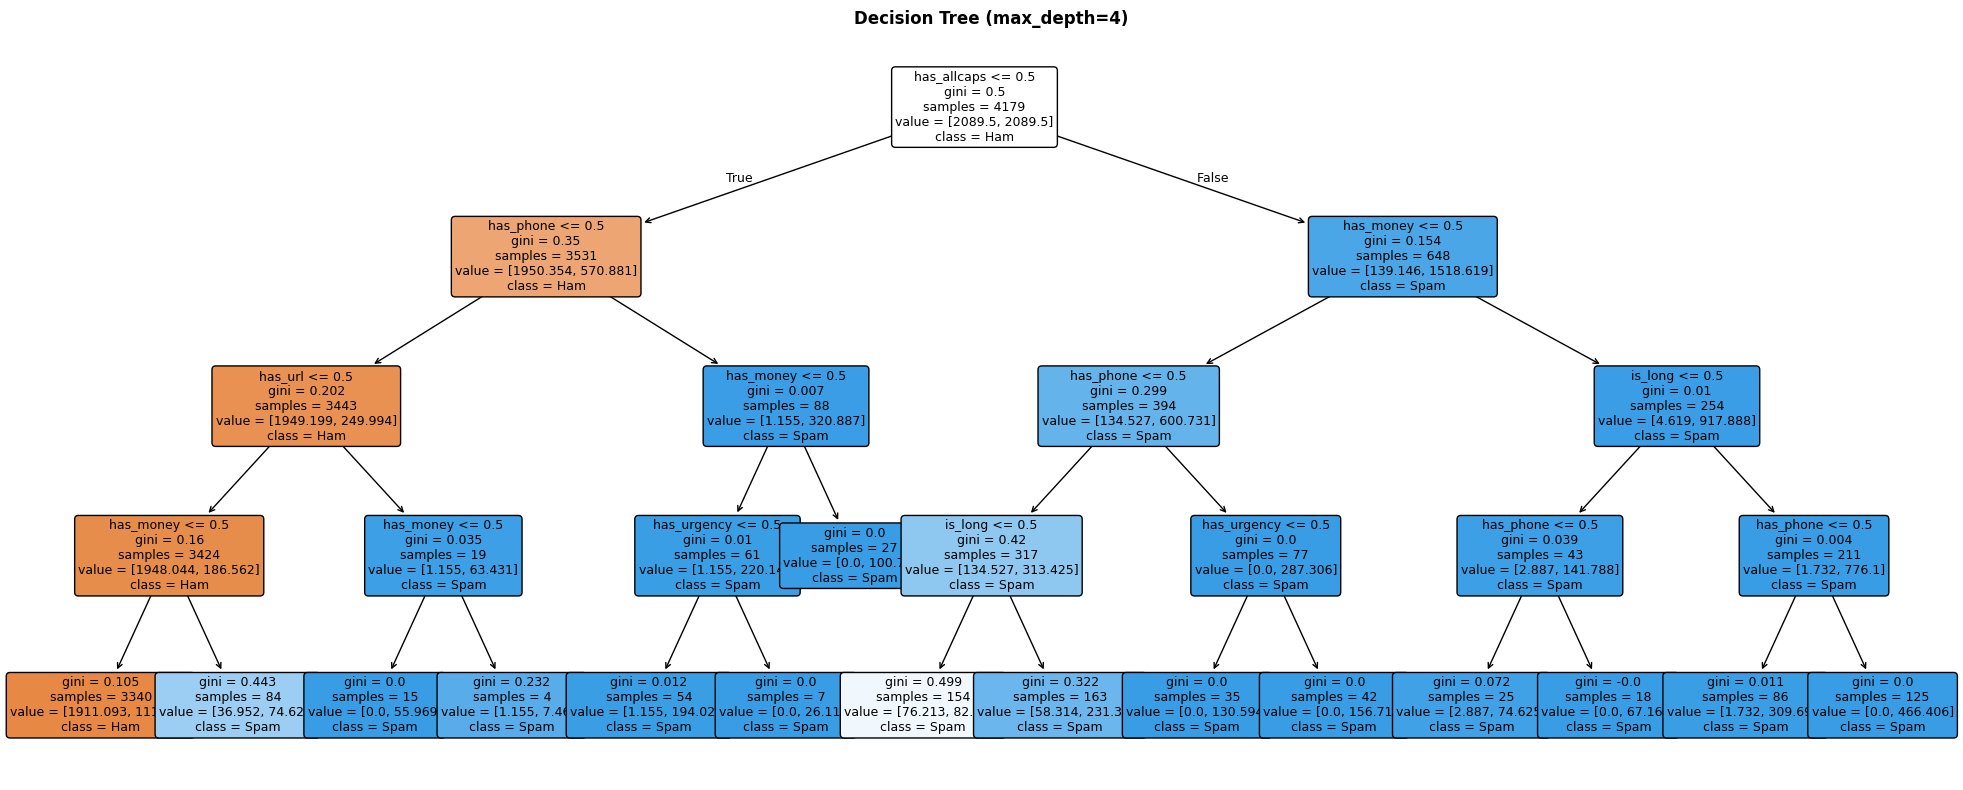

In [28]:
dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')
dt.fit(X_train, y_train)

print(f'Number of leaves: {dt.get_n_leaves()}')
print()
print(export_text(dt, feature_names=feature_cols))

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(dt, feature_names=feature_cols, class_names=['Ham', 'Spam'],
          filled=True, rounded=True, fontsize=9, ax=ax)
plt.title('Decision Tree (max_depth=4)', fontweight='bold')
plt.tight_layout()
plt.show()


### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


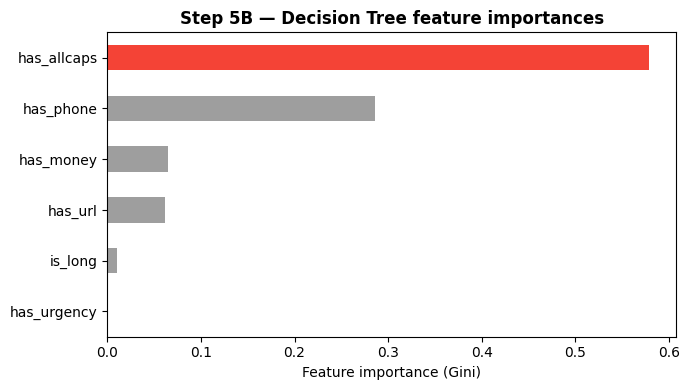

In [29]:
importances = pd.Series(dt.feature_importances_, index=feature_cols).sort_values()
colors = ['#F44336' if i == importances.idxmax() else '#9E9E9E'
          for i in importances.index]

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', color=colors, ax=ax)
ax.set_xlabel('Feature importance (Gini)')
ax.set_title('Step 5B — Decision Tree feature importances', fontweight='bold')
plt.tight_layout()
plt.show()


### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


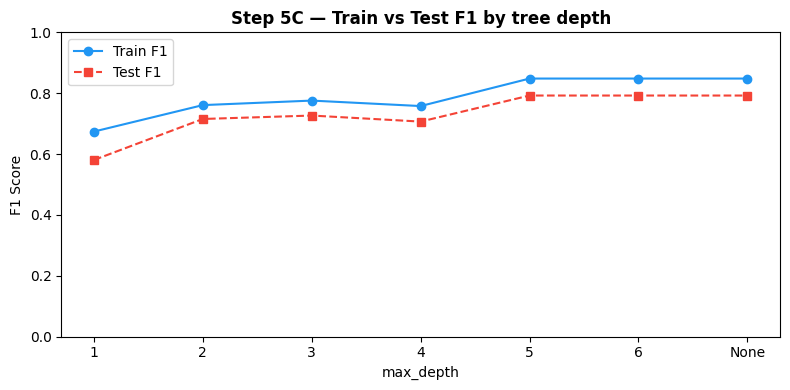

In [30]:
depths = [1, 2, 3, 4, 5, 6, None]
train_f1s, test_f1s = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42, class_weight='balanced')
    clf.fit(X_train, y_train)
    train_f1s.append(f1_score(y_train, clf.predict(X_train)))
    test_f1s.append(f1_score(y_test, clf.predict(X_test)))

labels = [str(d) if d is not None else 'None' for d in depths]
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(labels, train_f1s, 'o-', label='Train F1', color='#2196F3')
ax.plot(labels, test_f1s, 's--', label='Test F1', color='#F44336')
ax.set_xlabel('max_depth')
ax.set_ylabel('F1 Score')
ax.set_title('Step 5C — Train vs Test F1 by tree depth', fontweight='bold')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [31]:
nb = BernoulliNB()
nb.fit(X_train, y_train)
print('Naive Bayes trained successfully.')


Naive Bayes trained successfully.


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


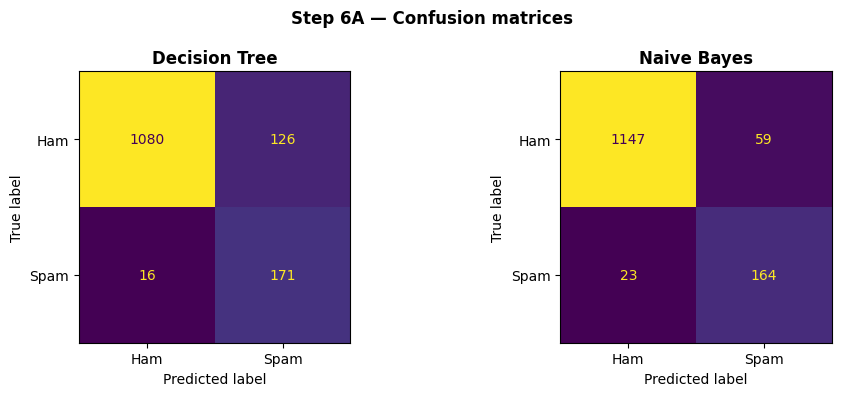


Decision Tree:
  TP (spam caught)        = 171
  FP (ham wrongly blocked)= 126
  FN (spam missed)        = 16
  TN (ham correctly passed)= 1080

Naive Bayes:
  TP (spam caught)        = 164
  FP (ham wrongly blocked)= 59
  FN (spam missed)        = 23
  TN (ham correctly passed)= 1147


In [32]:
y_pred_dt = dt.predict(X_test)
y_pred_nb = nb.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, preds, name in zip(axes, [y_pred_dt, y_pred_nb],
                            ['Decision Tree', 'Naive Bayes']):
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=['Ham', 'Spam'],
        colorbar=False, ax=ax)
    ax.set_title(name, fontweight='bold')

plt.suptitle('Step 6A — Confusion matrices', fontweight='bold')
plt.tight_layout()
plt.show()

for preds, name in [(y_pred_dt, 'Decision Tree'), (y_pred_nb, 'Naive Bayes')]:
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    print(f'\n{name}:')
    print(f'  TP (spam caught)        = {tp}')
    print(f'  FP (ham wrongly blocked)= {fp}')
    print(f'  FN (spam missed)        = {fn}')
    print(f'  TN (ham correctly passed)= {tn}')

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


               Accuracy  Precision  Recall  F1-Score
Model                                               
Decision Tree    0.8981     0.5758  0.9144    0.7066
Naive Bayes      0.9411     0.7354  0.8770    0.8000


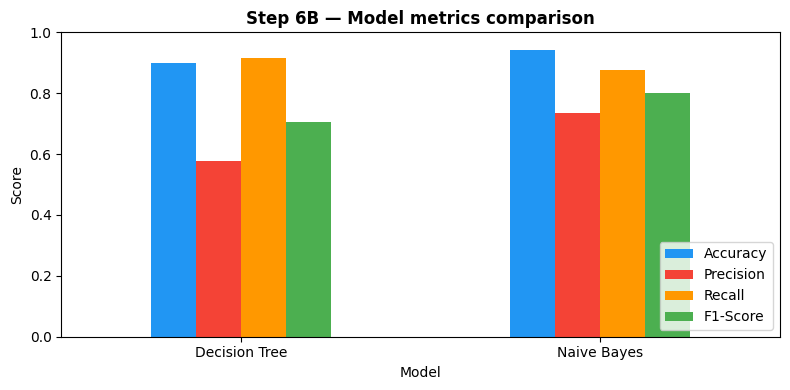

In [33]:
rows = []
for preds, name in [(y_pred_dt, 'Decision Tree'), (y_pred_nb, 'Naive Bayes')]:
    rows.append({
        'Model': name,
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall'   : recall_score(y_test, preds),
        'F1-Score' : f1_score(y_test, preds),
    })

metrics_df = pd.DataFrame(rows).set_index('Model')
print(metrics_df.round(4))

ax = metrics_df.plot(kind='bar', figsize=(8, 4), rot=0,
                     color=['#2196F3', '#F44336', '#FF9800', '#4CAF50'])
ax.set_ylabel('Score')
ax.set_title('Step 6B — Model metrics comparison', fontweight='bold')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [34]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for clf, name in [(dt, 'Decision Tree'), (nb, 'Naive Bayes')]:
    scores = cross_val_score(clf, X, y, cv=skf, scoring='f1')
    print(f'{name}: CV F1 = {scores.mean():.4f} ± {scores.std():.4f}')
    print(f'  Per-fold: {[f"{s:.4f}" for s in scores]}')

Decision Tree: CV F1 = 0.8044 ± 0.0395
  Per-fold: ['0.8239', '0.8224', '0.8242', '0.7253', '0.8261']
Naive Bayes: CV F1 = 0.8374 ± 0.0182
  Per-fold: ['0.8297', '0.8187', '0.8418', '0.8705', '0.8261']


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> Correctly collected spam 171, missed 16 spam messages, and wrongly blocked 126 legitimate messages.

*Naive Bayes:*
> Correctly caught 164 spam messages, missed 23 spam messages, and wrongly blocked 59 legitimate messages.

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> Precision is the primary metric from Q1b. Naive Bayes wins clearly, it blocked 59 ham messages versus the Decision Tree's 126, translating to a much higher precision. The cross-validation results from Step 6C confirm this: Naive Bayes achieved a mean F1 of 0.8374 compared to 0.8044 for the Decision Tree, with more consistent scores across folds as well.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
>I recommend Naive Bayes for deployment. It wrongly blocked only 59 legitimate messages compared to 126 for the Decision Tree, making it significantly safer for users who rely on SMS for important communications. The main weakness is that it missed 23 spam messages, so some junk will still get through. To improve this, we could add TF-IDF word frequency features to help the model detect spam vocabulary beyond the six binary flags it currently uses.


**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> The two features most likely to fail on modern spam are has_allcaps and has_urgency. Modern spam often impersonates banks or delivery services using professional, calm language, no shouted all-caps words or explicit phrases like "urgent" or "expires" appear. Both features were built around aggressive early-2010s bulk SMS patterns that spammers have since abandoned to evade exactly these kinds of filters.
